Q7: No, the problem is non-convex because the objective function involves the product of two optimization variables,
U and
V, making it bilinear and non-convex.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
!pip3 install surprise
from surprise import Dataset, Reader
from surprise.model_selection import cross_validate
from surprise.prediction_algorithms.knns import KNNWithMeans

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.4/154.4 kB 2.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for scikit-surprise: filename=scikit_surprise-1.1.4-cp311-cp311-linux_x86_64.whl size=2505185 sha256=c62521b03a9955d8f933caa1ed83c58f7fcb07404a367e049588290cebc3b026
  Stored in directory: /root/.cache/pip/wheels/2a/8f/6e/7e2899163e2d85d8266daab4aa1cdabec7a6c56f83c015b5af
Successfully built scikit-surprise


In [2]:
from surprise.model_selection import KFold
from surprise import accuracy
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from surprise.model_selection import train_test_split
from surprise.prediction_algorithms.matrix_factorization import NMF
from surprise.prediction_algorithms.matrix_factorization import SVD
from sklearn.metrics import mean_squared_error

In [3]:
import pandas as pd

df = pd.read_csv("ratings.csv")
df = df[["userId", "movieId", "rating"]]

print(df.head())

FileNotFoundError: [Errno 2] No such file or directory: 'ratings.csv'

In [31]:
from surprise import Dataset, Reader

reader = Reader(rating_scale=(df["rating"].min(), df["rating"].max()))
data = Dataset.load_from_df(df[["userId", "movieId", "rating"]], reader)


In [32]:
from surprise import NMF
from surprise.model_selection import cross_validate

k_values = list(range(2, 52, 2))
rmse_values = []
mae_values = []

for k in k_values:
    algo = NMF(n_factors=k)
    cv_results = cross_validate(algo, data, cv=10, measures=["RMSE", "MAE"], verbose=False)

    avg_rmse = np.mean(cv_results["test_rmse"])
    avg_mae = np.mean(cv_results["test_mae"])

    rmse_values.append(avg_rmse)
    mae_values.append(avg_mae)

print("Training completed!")


Training completed!


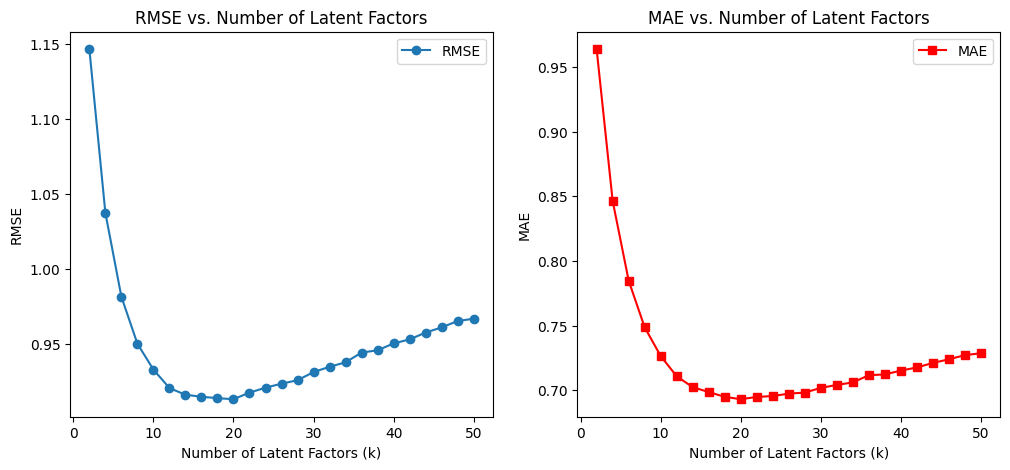

In [33]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(k_values, rmse_values, marker='o', label="RMSE")
plt.xlabel("Number of Latent Factors (k)")
plt.ylabel("RMSE")
plt.title("RMSE vs. Number of Latent Factors")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(k_values, mae_values, marker='s', label="MAE", color="red")
plt.xlabel("Number of Latent Factors (k)")
plt.ylabel("MAE")
plt.title("MAE vs. Number of Latent Factors")
plt.legend()

plt.show()


In [34]:
optimal_k_rmse = k_values[np.argmin(rmse_values)]
optimal_k_mae = k_values[np.argmin(mae_values)]
min_rmse = min(rmse_values)
min_mae = min(mae_values)

print(f"Optimal k (RMSE): {optimal_k_rmse}, Minimum RMSE: {min_rmse:.4f}")
print(f"Optimal k (MAE): {optimal_k_mae}, Minimum MAE: {min_mae:.4f}")


Optimal k (RMSE): 20, Minimum RMSE: 0.9130
Optimal k (MAE): 20, Minimum MAE: 0.6932


In [35]:
movies_df = pd.read_csv("movies.csv")
movies_df["genres"] = movies_df["genres"].apply(lambda x: x.split("|"))  # 分割多个类别
unique_genres = set([genre for sublist in movies_df["genres"] for genre in sublist])

print(f"Number of unique movie genres: {len(unique_genres)}")
print(f"Optimal k (RMSE): {optimal_k_rmse}")
print(f"Optimal k (MAE): {optimal_k_mae}")


Number of unique movie genres: 20
Optimal k (RMSE): 20
Optimal k (MAE): 20


In [64]:
movie_stats = df.groupby("movieId").agg(
    count=("rating", "count"),
    variance=("rating", "var")
).fillna(0)

popular_movies = movie_stats[movie_stats["count"] > 2].index
unpopular_movies = movie_stats[movie_stats["count"] <= 2].index
high_variance_movies = movie_stats[(movie_stats["variance"] >= 2) & (movie_stats["count"] >= 5)].index

df_popular = df[df["movieId"].isin(popular_movies)]
df_unpopular = df[df["movieId"].isin(unpopular_movies)]
df_high_variance = df[df["movieId"].isin(high_variance_movies)]

print("Popular movies dataset size:", df_popular.shape)
print("Unpopular movies dataset size:", df_unpopular.shape)
print("High variance movies dataset size:", df_high_variance.shape)


Popular movies dataset size: (94794, 4)
Unpopular movies dataset size: (6042, 4)
High variance movies dataset size: (588, 4)


In [66]:
subset_rmse = { "Popular": [], "Unpopular": [], "HighVariance": [] }
k_values = list(range(2, 52, 2))

for subset_name, subset_df in zip(
    ["Popular", "Unpopular", "HighVariance"],
    [df_popular, df_unpopular, df_high_variance]
):
    reader = Reader(rating_scale=(df["rating"].min(), df["rating"].max()))
    subset_data = Dataset.load_from_df(subset_df[["userId", "movieId", "rating"]], reader)

    for k in k_values:
        nmf = NMF(n_factors=k, random_state=42, verbose=False)
        cv = cross_validate(nmf, subset_data, measures=["RMSE"], cv=10, verbose=False)
        subset_rmse[subset_name].append(np.mean(cv["test_rmse"]))

print("Training completed for all subsets!")

Training completed for all subsets!


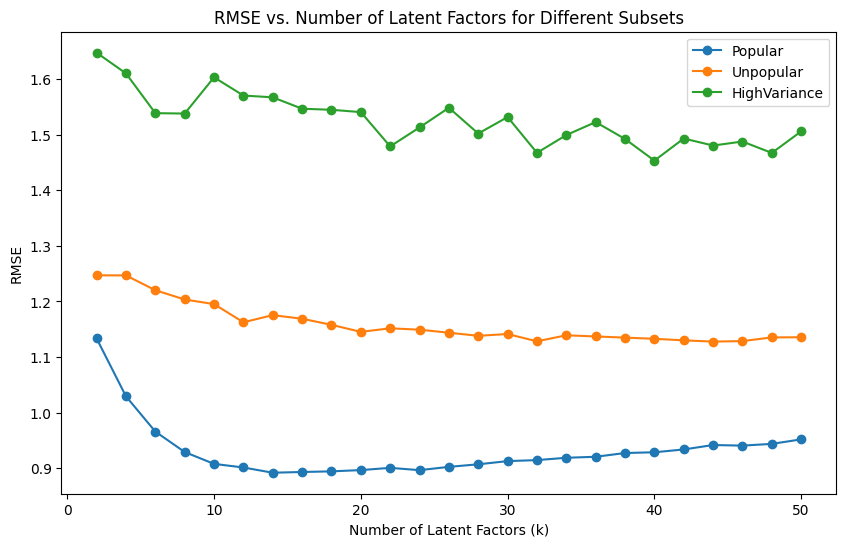

In [67]:
plt.figure(figsize=(10, 6))

for subset_name, rmse_values in subset_rmse.items():
    plt.plot(k_values, rmse_values, marker='o', label=subset_name)

plt.xlabel("Number of Latent Factors (k)")
plt.ylabel("RMSE")
plt.title("RMSE vs. Number of Latent Factors for Different Subsets")
plt.legend()
plt.show()

In [68]:
for subset_name, rmse_values in subset_rmse.items():
    min_rmse = min(rmse_values)
    optimal_k = k_values[np.argmin(rmse_values)]
    print(f"Subset: {subset_name}, Optimal k: {optimal_k}, Minimum RMSE: {min_rmse:.4f}")


Subset: Popular, Optimal k: 14, Minimum RMSE: 0.8921
Subset: Unpopular, Optimal k: 44, Minimum RMSE: 1.1279
Subset: HighVariance, Optimal k: 40, Minimum RMSE: 1.4533


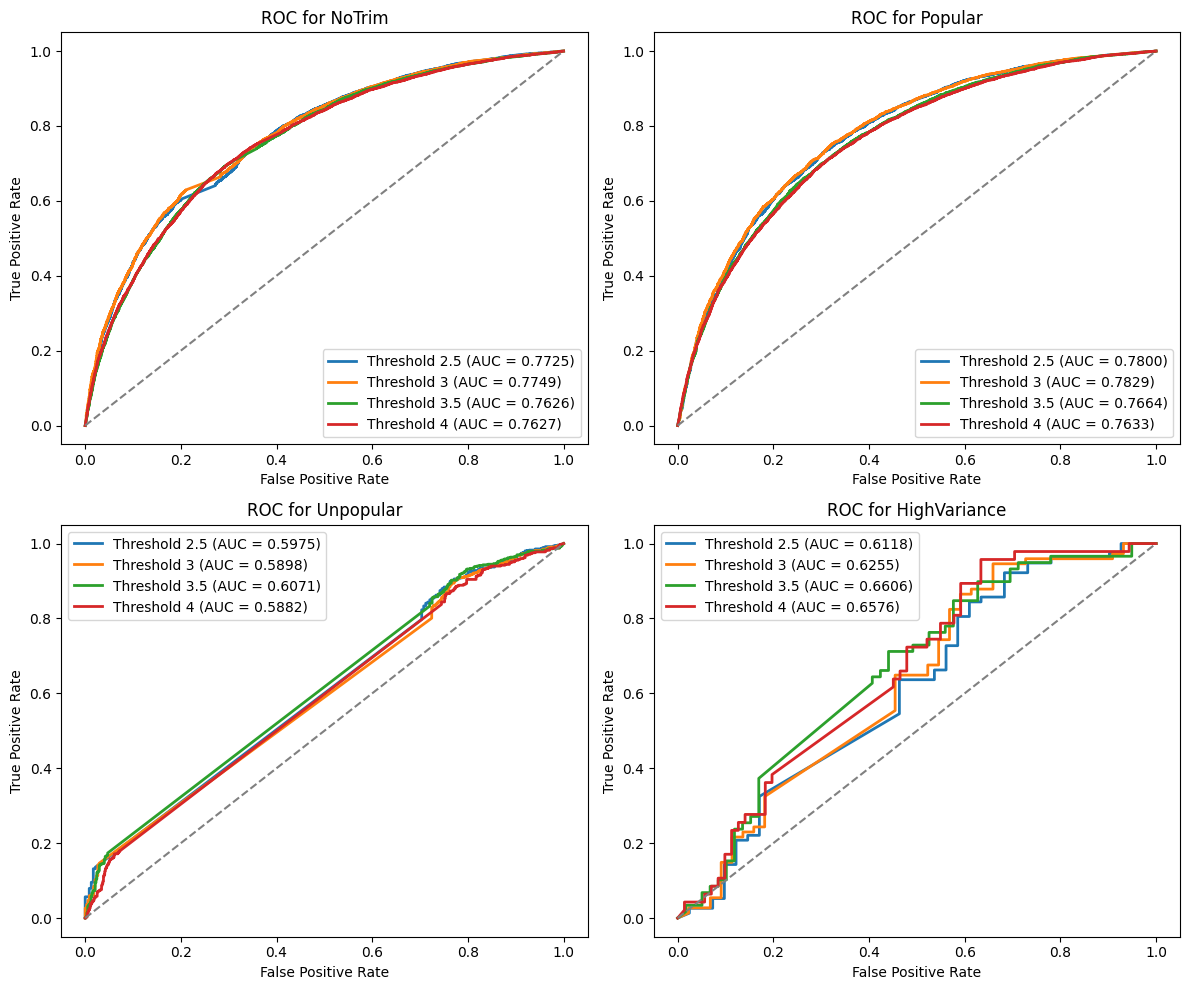

In [95]:
thresholds = [2.5, 3, 3.5, 4]
roc_results_fixed = { "NoTrim": {}, "Popular": {}, "Unpopular": {}, "HighVariance": {} }

for subset_name, subset_df in zip(
    ["NoTrim", "Popular", "Unpopular", "HighVariance"],
    [df, df_popular, df_unpopular, df_high_variance]
):
    reader = Reader(rating_scale=(df["rating"].min(), df["rating"].max()))
    subset_data = Dataset.load_from_df(subset_df[["userId", "movieId", "rating"]], reader)

    trainset, testset = train_test_split(subset_data, test_size=0.2, random_state=42)

    nmf = NMF(n_factors=optimal_k_rmse, random_state=42)
    nmf.fit(trainset)

    true_labels = []
    predicted_scores = []

    for uid, iid, true_rating in testset:
        pred = nmf.predict(uid, iid).est
        true_labels.append(true_rating)
        predicted_scores.append(pred)

    for threshold in thresholds:
        binary_labels = [1 if r >= threshold else 0 for r in true_labels]
        fpr, tpr, _ = roc_curve(binary_labels, predicted_scores)
        roc_auc = auc(fpr, tpr)
        roc_results_fixed[subset_name][threshold] = (fpr, tpr, roc_auc)

plt.figure(figsize=(12, 10))
for i, subset_name in enumerate(roc_results_fixed.keys()):
    plt.subplot(2, 2, i + 1)
    for threshold, (fpr, tpr, roc_auc) in roc_results_fixed[subset_name].items():
        plt.plot(fpr, tpr, lw=2, label=f"Threshold {threshold} (AUC = {roc_auc:.4f})")

    plt.plot([0, 1], [0, 1], color="gray", linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC for {subset_name}")
    plt.legend()

plt.tight_layout()
plt.show()


Q9

In [75]:
nmf_k20 = NMF(n_factors=20, biased=False, random_state=42)
nmf_k20.fit(trainset)

V = np.zeros((20, trainset.n_items))

for item_id in range(trainset.n_items):
    raw_id = trainset.to_raw_iid(item_id)
    V[:, item_id] = nmf_k20.qi[item_id]

top_movies_per_factor = {}

for factor_idx in range(V.shape[0]):
    top_movie_indices = np.argsort(V[factor_idx])[-10:][::-1]
    top_movie_ids = [trainset.to_raw_iid(i) for i in top_movie_indices]
    top_movie_names = [movie_genres.get(int(mid), "Unknown") for mid in top_movie_ids]

    top_movies_per_factor[f"Factor {factor_idx + 1}"] = top_movie_names

for factor, movies in list(top_movies_per_factor.items())[:10]:
    print(f"\n{factor}:")
    print(", ".join(movies))



Factor 1:
Fantasy|Horror, Horror|Mystery|Thriller, Horror, Action|Crime|Thriller, Drama|Thriller, Drama|Horror|Thriller, Drama, Comedy|Drama, Action|Adventure, Crime|Horror|Mystery

Factor 2:
Children|Comedy, Comedy, Comedy|Fantasy|Horror, Comedy|Romance, Adventure|Comedy|Sci-Fi, Drama|War, Crime|Drama, Action|Comedy|Sci-Fi|Thriller, Comedy, Action|Adventure|Children|Comedy

Factor 3:
Comedy|Drama|Romance, Comedy|Crime, Action|Sci-Fi|Thriller, Documentary, Documentary, Romance|Thriller, Action|Children, Comedy, Comedy|Romance, Drama|War

Factor 4:
Action|Sci-Fi, Sci-Fi, Horror|Sci-Fi, Comedy|Drama, Comedy, Action|Drama|Fantasy, Horror|Sci-Fi, Action|Adventure|Animation|Children|Comedy|Romance, Drama, Drama|Romance|Western

Factor 5:
Action|Fantasy|Horror|Sci-Fi|Thriller, Comedy|Romance, Drama, Drama|Horror|Thriller, Action|Drama, Comedy|Fantasy, Thriller, Horror|Sci-Fi|Thriller, Comedy|Documentary, Comedy|Crime

Factor 6:
Animation|Children|Comedy|Musical, Adventure|Animation|Children

Q10

In [76]:
k_values = list(range(2, 52, 2))
rmse_values = []
mae_values = []

# Perform 10-fold cross-validation for each k
for k in k_values:
    algo = SVD(n_factors=k, biased=True)  # Use SVD with bias
    cv_results = cross_validate(algo, data, cv=10, measures=["RMSE", "MAE"], verbose=False)

    avg_rmse = np.mean(cv_results["test_rmse"])
    avg_mae = np.mean(cv_results["test_mae"])

    rmse_values.append(avg_rmse)
    mae_values.append(avg_mae)


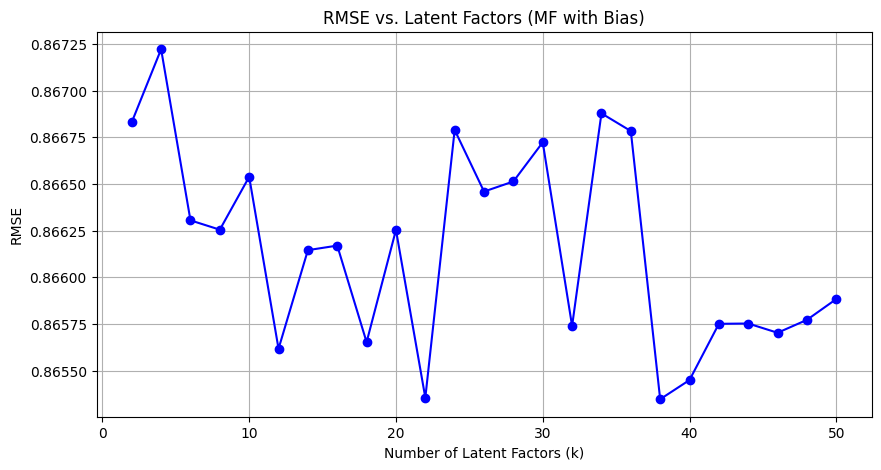

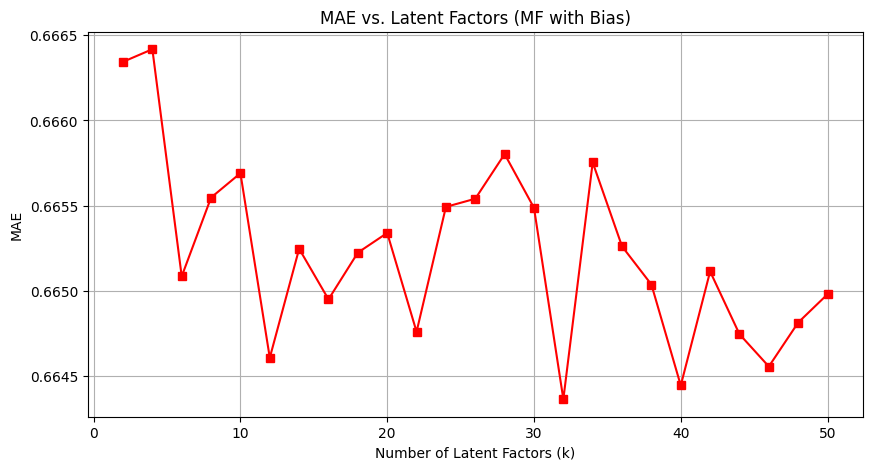

In [79]:
# Plot RMSE curve separately
plt.figure(figsize=(10, 5))
plt.plot(k_values, rmse_values, marker='o', color='b')
plt.xlabel("Number of Latent Factors (k)")
plt.ylabel("RMSE")
plt.title("RMSE vs. Latent Factors (MF with Bias)")
plt.grid()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(k_values, mae_values, marker='s', color='r')
plt.xlabel("Number of Latent Factors (k)")
plt.ylabel("MAE")
plt.title("MAE vs. Latent Factors (MF with Bias)")
plt.grid()
plt.show()


In [80]:

# Find best k
best_k_index = np.argmin(rmse_values)
best_k = k_values[best_k_index]
best_rmse = rmse_values[best_k_index]
best_mae = mae_values[best_k_index]

best_k, best_rmse, best_mae


(38, 0.8653478210495102, 0.665037894332046)

Q11

In [81]:
subset_rmse = { "Popular": [], "Unpopular": [], "HighVariance": [] }
k_values = list(range(2, 52, 2))

for subset_name, subset_df in zip(
    ["Popular", "Unpopular", "HighVariance"],
    [df_popular, df_unpopular, df_high_variance]
):
    reader = Reader(rating_scale=(df["rating"].min(), df["rating"].max()))
    subset_data = Dataset.load_from_df(subset_df[["userId", "movieId", "rating"]], reader)

    for k in k_values:
        algo = SVD(n_factors=k, biased=True)
        cv = cross_validate(algo, subset_data, measures=["RMSE"], cv=10, verbose=False)
        subset_rmse[subset_name].append(np.mean(cv["test_rmse"]))

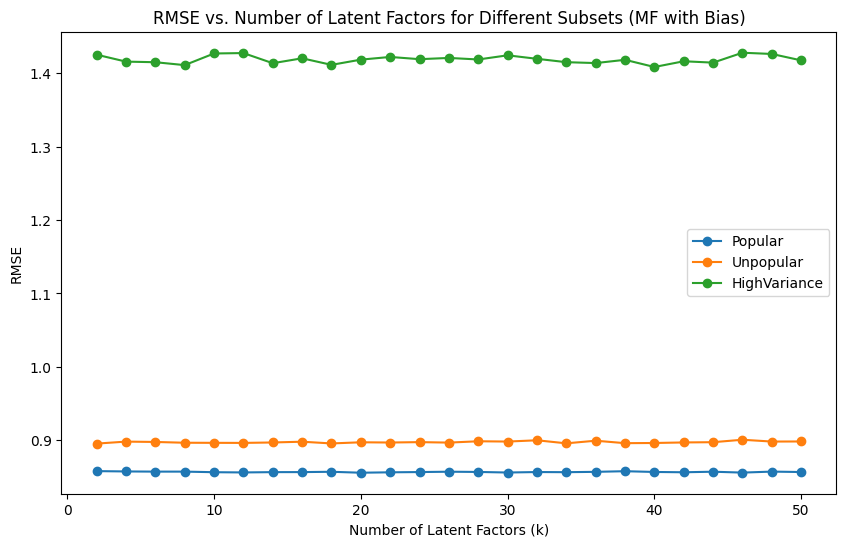

Subset: Popular, Optimal k: 20, Minimum RMSE: 0.8559
Subset: Unpopular, Optimal k: 2, Minimum RMSE: 0.8955
Subset: HighVariance, Optimal k: 40, Minimum RMSE: 1.4084


In [82]:
plt.figure(figsize=(10, 6))
for subset_name, rmse_values in subset_rmse.items():
    plt.plot(k_values, rmse_values, marker='o', label=subset_name)

plt.xlabel("Number of Latent Factors (k)")
plt.ylabel("RMSE")
plt.title("RMSE vs. Number of Latent Factors for Different Subsets (MF with Bias)")
plt.legend()
plt.show()

optimal_k_values = {}
for subset_name, rmse_values in subset_rmse.items():
    min_rmse = min(rmse_values)
    optimal_k = k_values[np.argmin(rmse_values)]
    optimal_k_values[subset_name] = optimal_k
    print(f"Subset: {subset_name}, Optimal k: {optimal_k}, Minimum RMSE: {min_rmse:.4f}")



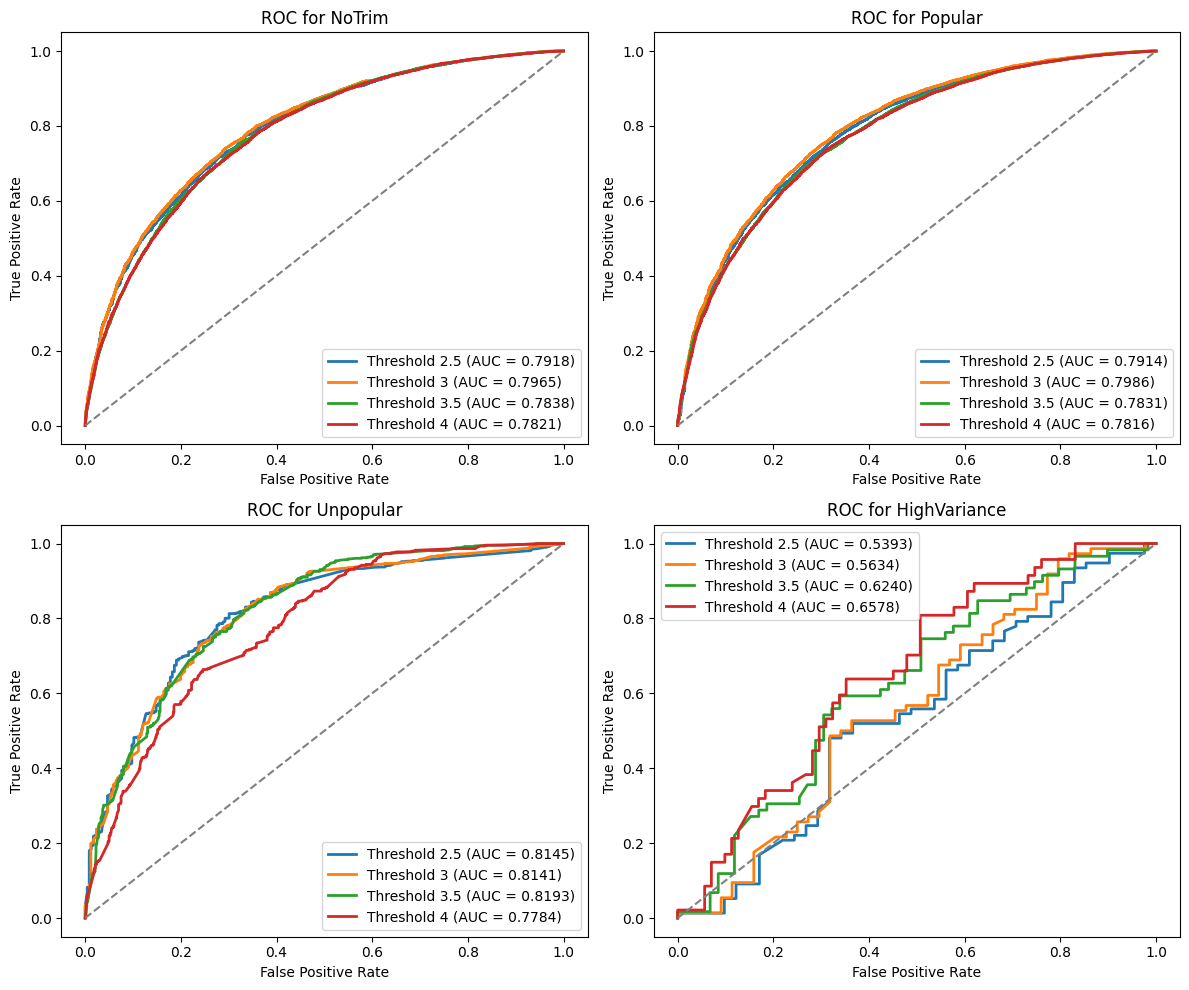

In [97]:
thresholds = [2.5, 3, 3.5, 4]
roc_results_fixed = { "NoTrim": {}, "Popular": {}, "Unpopular": {}, "HighVariance": {} }

for subset_name, subset_df in zip(
    ["NoTrim", "Popular", "Unpopular", "HighVariance"],
    [df, df_popular, df_unpopular, df_high_variance]
):
    reader = Reader(rating_scale=(df["rating"].min(), df["rating"].max()))
    subset_data = Dataset.load_from_df(subset_df[["userId", "movieId", "rating"]], reader)

    trainset, testset = train_test_split(subset_data, test_size=0.2, random_state=42)

    algo = SVD(n_factors=optimal_k_values.get(subset_name, 20), biased=True)
    algo.fit(trainset)

    true_labels = []
    predicted_scores = []

    for uid, iid, true_rating in testset:
        pred = algo.predict(uid, iid).est
        true_labels.append(true_rating)
        predicted_scores.append(pred)

    for threshold in thresholds:
        binary_labels = [1 if r >= threshold else 0 for r in true_labels]
        fpr, tpr, _ = roc_curve(binary_labels, predicted_scores)
        roc_auc = auc(fpr, tpr)
        roc_results_fixed[subset_name][threshold] = (fpr, tpr, roc_auc)

plt.figure(figsize=(12, 10))
for i, subset_name in enumerate(roc_results_fixed.keys()):
    plt.subplot(2, 2, i + 1)
    for threshold, (fpr, tpr, roc_auc) in roc_results_fixed[subset_name].items():
        plt.plot(fpr, tpr, lw=2, label=f"Threshold {threshold} (AUC = {roc_auc:.4f})")

    plt.plot([0, 1], [0, 1], color="gray", linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC for {subset_name}")
    plt.legend()

plt.tight_layout()
plt.show()


Q11

In [87]:
user_mean_ratings = df.groupby("userId")["rating"].mean().to_dict()
def naive_predict(user_id):
    return user_mean_ratings.get(user_id, np.mean(list(user_mean_ratings.values())))


In [89]:
from surprise.model_selection import KFold
from sklearn.metrics import mean_squared_error

kf = KFold(n_splits=10)
rmse_scores = []

for trainset, testset in kf.split(data):
    test_predictions = []
    test_actuals = []

    for uid, iid, actual_rating in testset:
        predicted_rating = naive_predict(uid)
        test_predictions.append(predicted_rating)
        test_actuals.append(actual_rating)

    rmse = np.sqrt(mean_squared_error(test_actuals, test_predictions))  # 修正 RMSE 计算
    rmse_scores.append(rmse)

avg_rmse = np.mean(rmse_scores)
print(f"Naïve Collaborative Filter - Average RMSE: {avg_rmse:.4f}")


Naïve Collaborative Filter - Average RMSE: 0.9347


In [90]:
subset_rmse = { "Popular": [], "Unpopular": [], "HighVariance": [] }
kf = KFold(n_splits=10)

for subset_name, subset_df in zip(
    ["Popular", "Unpopular", "HighVariance"],
    [df_popular, df_unpopular, df_high_variance]
):
    reader = Reader(rating_scale=(df["rating"].min(), df["rating"].max()))
    subset_data = Dataset.load_from_df(subset_df[["userId", "movieId", "rating"]], reader)

    for trainset, testset in kf.split(subset_data):
        test_predictions = []
        test_actuals = []

        for uid, iid, actual_rating in testset:
            predicted_rating = naive_predict(uid)
            test_predictions.append(predicted_rating)
            test_actuals.append(actual_rating)

        rmse = np.sqrt(mean_squared_error(test_actuals, test_predictions))
        subset_rmse[subset_name].append(rmse)

for subset_name, rmse_values in subset_rmse.items():
    avg_rmse = np.mean(rmse_values)
    print(f"Subset: {subset_name}, Average RMSE: {avg_rmse:.4f}")


Subset: Popular, Average RMSE: 0.9323
Subset: Unpopular, Average RMSE: 0.9710
Subset: HighVariance, Average RMSE: 1.3743


In [108]:
k_values = list(range(56, 60, 4))
rmse_values = []

kfold = KFold(n_splits=10, random_state=42)

for k in k_values:
    algo = KNNWithMeans(k=k, sim_options={'name': 'pearson'})
    fold_rmse = []

    for trainset, testset in kfold.split(data):
        algo.fit(trainset)
        predictions = algo.test(testset)
        fold_rmse.append(accuracy.rmse(predictions, verbose=False))

    rmse_values.append(np.mean(fold_rmse))

optimal_k = k_values[np.argmin(rmse_values)]
print(f"Optimal k: {optimal_k}, Minimum RMSE: {min(rmse_values):.4f}")


Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
Optimal k: 56, Minimum RMSE: 0.8897


Computing the cosine similarity matrix...
Done computing similarity matrix.


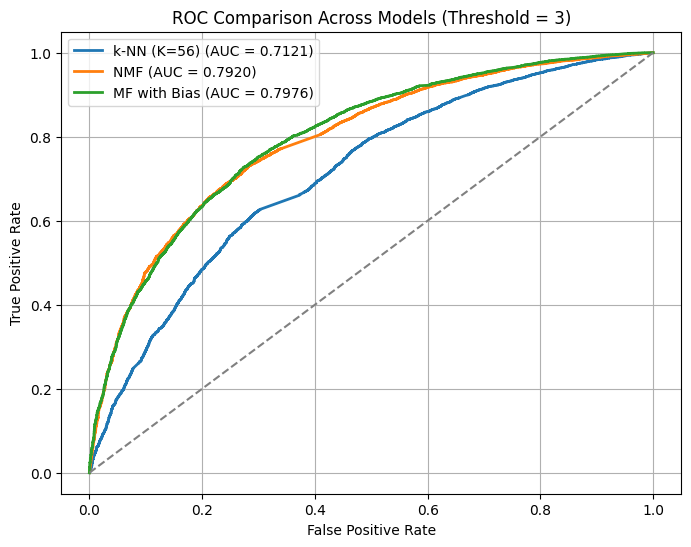

In [109]:
threshold = 3
roc_results_comparison = {}

models = {
    "k-NN (K={})".format(optimal_k): KNNBasic(k=optimal_k, sim_options={"name": "cosine", "user_based": True}),
    "NMF": NMF(n_factors=optimal_k, random_state=42),
    "MF with Bias": SVD(n_factors=optimal_k, biased=True)
}

reader = Reader(rating_scale=(df["rating"].min(), df["rating"].max()))
data_full = Dataset.load_from_df(df[["userId", "movieId", "rating"]], reader)
trainset, testset = train_test_split(data_full, test_size=0.2, random_state=42)
for model_name, algo in models.items():
    algo.fit(trainset)

    true_labels = []
    predicted_scores = []

    for uid, iid, true_rating in testset:
        pred = algo.predict(uid, iid).est
        true_labels.append(true_rating)
        predicted_scores.append(pred)

    binary_labels = [1 if r >= threshold else 0 for r in true_labels]
    fpr, tpr, _ = roc_curve(binary_labels, predicted_scores)
    roc_auc = auc(fpr, tpr)

    roc_results_comparison[model_name] = (fpr, tpr, roc_auc)

plt.figure(figsize=(8, 6))
for model_name, (fpr, tpr, roc_auc) in roc_results_comparison.items():
    plt.plot(fpr, tpr, lw=2, label=f"{model_name} (AUC = {roc_auc:.4f})")

plt.plot([0, 1], [0, 1], color="gray", linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Comparison Across Models (Threshold = 3)")
plt.legend()
plt.grid()
plt.show()
